# Notebook 06 - Sales Forecasting

## Objective
The goal of this notebook is to build a time-series forecasting pipeline for the Olist e-commerce dataset and predict future **daily revenue**.

This notebook focuses on:
- building a clean daily revenue time series
- visualizing historical revenue patterns
- splitting the data into train and test sets
- creating baseline and statistical forecasting models
- evaluating forecast accuracy using standard error metrics

## Business Value
Forecasting daily revenue can help:
- plan expected sales
- support inventory and seller readiness
- identify seasonality and revenue trends
- improve operational and financial planning

## Environment note
This notebook uses `statsmodels` for time-series forecasting.  
If the import below fails with a `deprecate_kwarg()` / `ExponentialSmoothing` error, install compatible versions in the notebook environment:

```bash
python -m pip uninstall -y statsmodels pandas scipy
python -m pip install pandas==2.2.2 scipy==1.13.1 statsmodels==0.14.2

In [2]:
# ======================================================
# Section 2 - Import Libraries
# ======================================================

import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import statsmodels.api as sm

In [3]:
# ======================================================
# Section 3 - Set Paths and Load Required Files
# ======================================================

from pathlib import Path
import pandas as pd

DATA_DIR = Path(r"C:\Users\divya\Downloads\Retail-Intelligence-Platform\data\raw")

orders_path = DATA_DIR / "olist_orders_dataset.csv"
payments_path = DATA_DIR / "olist_order_payments_dataset.csv"

orders = pd.read_csv(orders_path)
payments = pd.read_csv(payments_path)

print("Orders path  :", orders_path)
print("Payments path:", payments_path)

print("Orders shape  :", orders.shape)
print("Payments shape:", payments.shape)

display(orders.head())
display(payments.head())

Orders path  : C:\Users\divya\Downloads\Retail-Intelligence-Platform\data\raw\olist_orders_dataset.csv
Payments path: C:\Users\divya\Downloads\Retail-Intelligence-Platform\data\raw\olist_order_payments_dataset.csv
Orders shape  : (99441, 8)
Payments shape: (103886, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [4]:
# ======================================================
# Section 4 - Inspect Required Columns
# ======================================================

print("Orders columns:")
print(orders.columns.tolist())

print("\nPayments columns:")
print(payments.columns.tolist())

print("\nOrder status distribution:")
display(orders["order_status"].value_counts(dropna=False))

Orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Payments columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']

Order status distribution:


order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [5]:
# ======================================================
# Section 5 - Convert Date Columns
# ======================================================

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

print("Null timestamps:", orders["order_purchase_timestamp"].isna().sum())

display(
    orders[["order_id", "order_status", "order_purchase_timestamp"]].head()
)

Null timestamps: 0


,order_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,2018-02-13 21:18:39


## Baseline / Naive Forecast
The baseline forecast uses the last observed training-day revenue as the prediction for all future test days. This provides a simple benchmark to evaluate whether statistical forecasting models improve over a naive assumption.

### Holt-Winters Assumption
A seasonal period of 7 days is used to capture weekly seasonality in daily e-commerce revenue, since customer purchase behavior often varies by day of week.

In [6]:
# ======================================================
# Section 6 - Filter Delivered Orders
# ======================================================

orders_delivered = orders.loc[
    orders["order_status"] == "delivered",
    ["order_id", "order_purchase_timestamp", "order_status"]
].copy()

print("Delivered orders shape:", orders_delivered.shape)
display(orders_delivered.head())

Delivered orders shape: (96478, 3)


,order_id,order_purchase_timestamp,order_status
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,delivered
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,delivered
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,delivered
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,delivered
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,delivered


In [7]:
# ======================================================
# Section 7 - Merge Orders and Payments
# ======================================================

forecast_df = orders_delivered.merge(
    payments[["order_id", "payment_value"]],
    on="order_id",
    how="inner"
)

print("Merged forecasting dataframe shape:", forecast_df.shape)
display(forecast_df.head())

Merged forecasting dataframe shape: (100756, 4)


,order_id,order_purchase_timestamp,order_status,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,delivered,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,delivered,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,delivered,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,delivered,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,delivered,179.12


In [8]:
# ======================================================
# Section 8 - Create Daily Revenue Time Series
# ======================================================

daily_revenue = (
    forecast_df
    .groupby(forecast_df["order_purchase_timestamp"].dt.date)["payment_value"]
    .sum()
    .reset_index()
)

daily_revenue.columns = ["Date", "Revenue"]
daily_revenue["Date"] = pd.to_datetime(daily_revenue["Date"])

daily_revenue = daily_revenue.sort_values("Date").reset_index(drop=True)

print("Daily revenue shape:", daily_revenue.shape)
display(daily_revenue.head())
display(daily_revenue.tail())

Daily revenue shape: (611, 2)


,Date,Revenue
0,2016-10-03,559.53
1,2016-10-04,9821.42
2,2016-10-05,7209.50
3,2016-10-06,6733.52
4,2016-10-07,6832.76


,Date,Revenue
606,2018-08-25,11737.76
607,2018-08-26,9304.00
608,2018-08-27,6111.60
609,2018-08-28,4121.23
610,2018-08-29,1762.70


In [9]:
# ======================================================
# Section 9 - Reindex to Daily Frequency
# ======================================================

daily_revenue = daily_revenue.set_index("Date")

full_date_range = pd.date_range(
    start=daily_revenue.index.min(),
    end=daily_revenue.index.max(),
    freq="D"
)

daily_revenue = daily_revenue.reindex(full_date_range)

daily_revenue.index.name = "Date"
daily_revenue["Revenue"] = daily_revenue["Revenue"].fillna(0)

print("Daily revenue after reindexing:", daily_revenue.shape)
display(daily_revenue.head())
display(daily_revenue.tail())

Daily revenue after reindexing: (696, 1)


,Revenue
Date,
2016-10-03,559.53
2016-10-04,9821.42
2016-10-05,7209.50
2016-10-06,6733.52
2016-10-07,6832.76


,Revenue
Date,
2018-08-25,11737.76
2018-08-26,9304.00
2018-08-27,6111.60
2018-08-28,4121.23
2018-08-29,1762.70


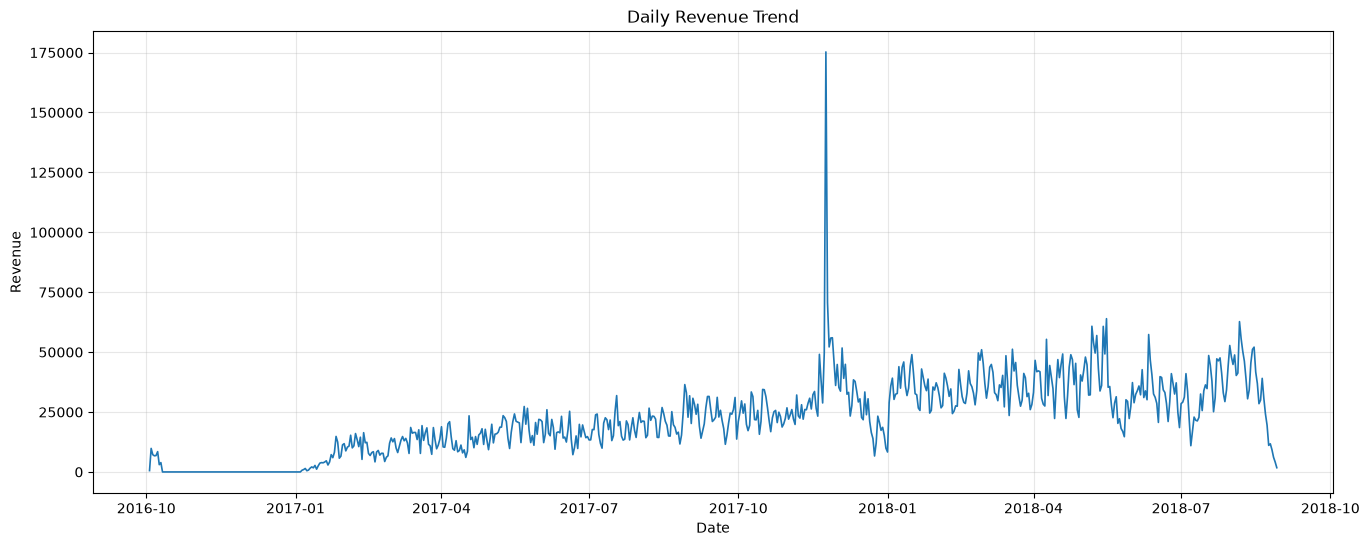

In [10]:
# ======================================================
# Section 10 - Plot Daily Revenue Trend
# ======================================================

plt.figure(figsize=(16, 6))
plt.plot(daily_revenue.index, daily_revenue["Revenue"], linewidth=1.2)
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.grid(True, alpha=0.3)
plt.show()

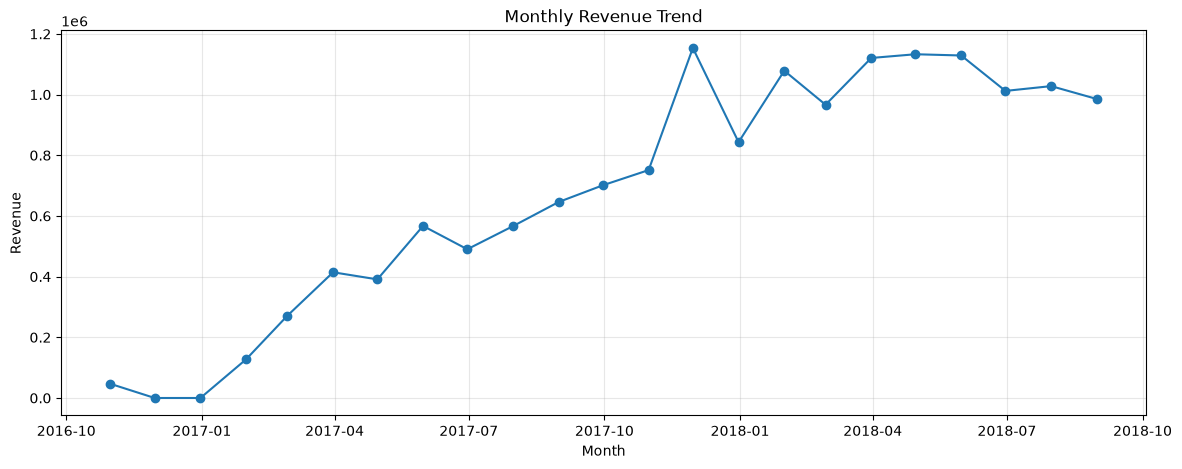

,Date,Revenue
0,2016-10-31,46566.71
1,2016-11-30,0.00
2,2016-12-31,19.62
3,2017-01-31,127545.67
4,2017-02-28,271298.65


In [11]:
# ======================================================
# Section 11 - Monthly Revenue Trend
# ======================================================

monthly_revenue = (
    daily_revenue["Revenue"]
    .resample("M")
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue["Date"], monthly_revenue["Revenue"], marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True, alpha=0.3)
plt.show()

display(monthly_revenue.head())

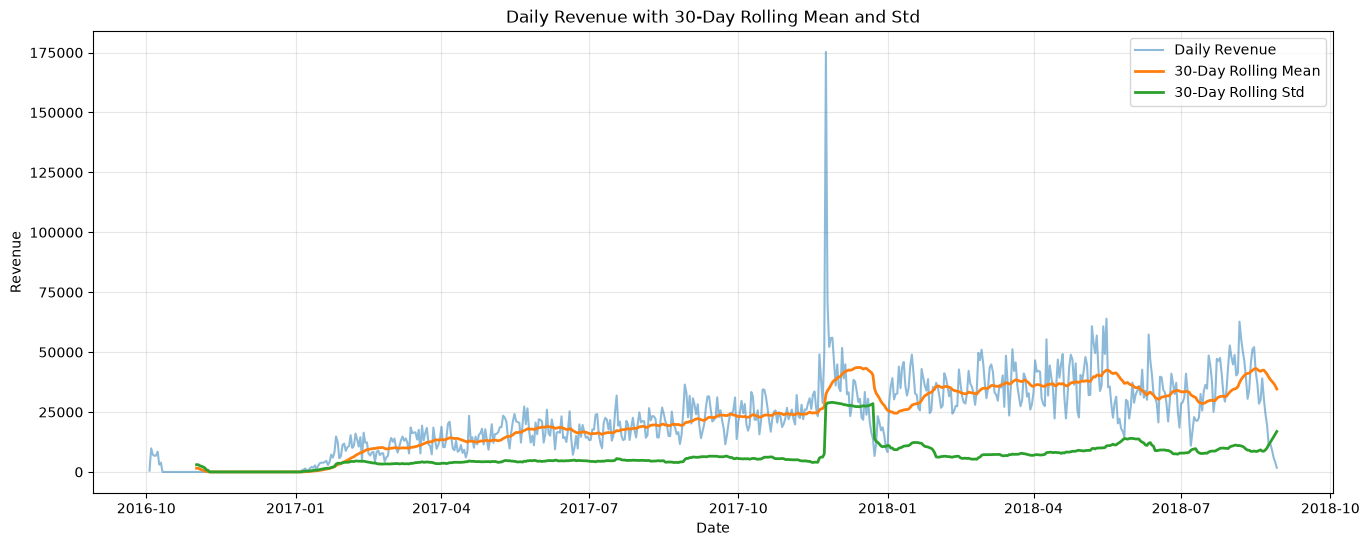

In [12]:
# ======================================================
# Section 12 - Rolling Mean and Rolling Std
# ======================================================

rolling_window = 30

daily_revenue["Rolling_Mean_30"] = daily_revenue["Revenue"].rolling(rolling_window).mean()
daily_revenue["Rolling_Std_30"] = daily_revenue["Revenue"].rolling(rolling_window).std()

plt.figure(figsize=(16, 6))
plt.plot(daily_revenue.index, daily_revenue["Revenue"], label="Daily Revenue", alpha=0.5)
plt.plot(daily_revenue.index, daily_revenue["Rolling_Mean_30"], label="30-Day Rolling Mean", linewidth=2)
plt.plot(daily_revenue.index, daily_revenue["Rolling_Std_30"], label="30-Day Rolling Std", linewidth=2)
plt.title("Daily Revenue with 30-Day Rolling Mean and Std")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# ======================================================
# Section 13 - Train Test Split
# ======================================================

test_days = 30

train = daily_revenue.iloc[:-test_days].copy()
test = daily_revenue.iloc[-test_days:].copy()

print("Train shape:", train.shape)
print("Test shape :", test.shape)

print("\nTrain date range:")
print(train.index.min(), "to", train.index.max())

print("\nTest date range:")
print(test.index.min(), "to", test.index.max())

Train shape: (666, 3)
Test shape : (30, 3)

Train date range:
2016-10-03 00:00:00 to 2018-07-30 00:00:00

Test date range:
2018-07-31 00:00:00 to 2018-08-29 00:00:00


In [14]:
# ======================================================
# Section 14 - Baseline Forecast
# ======================================================

baseline_forecast = np.repeat(train["Revenue"].iloc[-1], len(test))

baseline_results = pd.DataFrame({
    "Actual": test["Revenue"].values,
    "Baseline_Forecast": baseline_forecast
}, index=test.index)

display(baseline_results.head())

,Actual,Baseline_Forecast
Date,,
2018-07-31,52768.27,44165.92
2018-08-01,48066.11,44165.92
2018-08-02,44852.24,44165.92
2018-08-03,48819.75,44165.92
2018-08-04,40250.11,44165.92


In [15]:
# ======================================================
# Section 15 - Holt-Winters Model
# ======================================================

hw_model = ExponentialSmoothing(
    train["Revenue"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit()

hw_forecast = hw_model.forecast(len(test))

hw_mae = mean_absolute_error(test["Revenue"], hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(test["Revenue"], hw_forecast))

print("Holt-Winters MAE :", round(hw_mae, 2))
print("Holt-Winters RMSE:", round(hw_rmse, 2))

Holt-Winters MAE : 12912.41
Holt-Winters RMSE: 17902.65


In [16]:
# ======================================================
# Section 16 - ADF Test for Stationarity
# ======================================================

def adf_test(series, title="Time Series"):
    """
    Perform Augmented Dickey-Fuller test and print results.
    """
    result = adfuller(series.dropna())
    
    print(f"ADF Test - {title}")
    print("-" * 50)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"p-value       : {result[1]:.4f}")
    print(f"Lags Used     : {result[2]}")
    print(f"Observations  : {result[3]}")
    print("\nCritical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    
    if result[1] < 0.05:
        print("\nResult: Series appears STATIONARY")
    else:
        print("\nResult: Series appears NON-STATIONARY")

adf_test(train["Revenue"], title="Train Revenue")

ADF Test - Train Revenue
--------------------------------------------------
ADF Statistic : -1.7593
p-value       : 0.4009
Lags Used     : 20
Observations  : 645

Critical Values:
   1%: -3.4405
   5%: -2.8660
   10%: -2.5692

Result: Series appears NON-STATIONARY


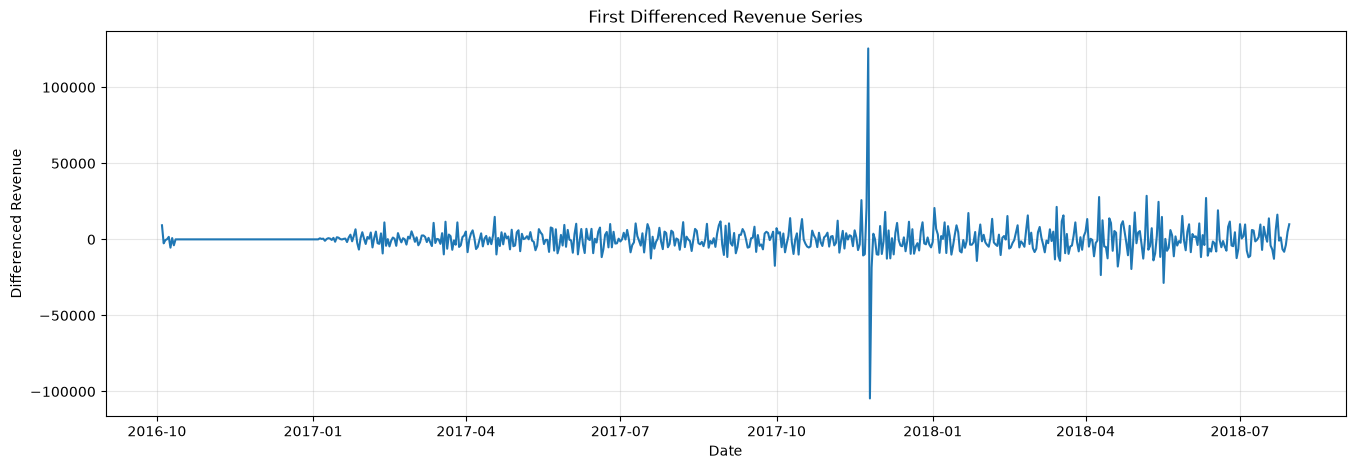

ADF Test - First Differenced Train Revenue
--------------------------------------------------
ADF Statistic : -8.8274
p-value       : 0.0000
Lags Used     : 19
Observations  : 645

Critical Values:
   1%: -3.4405
   5%: -2.8660
   10%: -2.5692

Result: Series appears STATIONARY


In [17]:
# ======================================================
# Section 17 - First Differencing
# ======================================================

train_diff_1 = train["Revenue"].diff().dropna()

plt.figure(figsize=(16, 5))
plt.plot(train_diff_1.index, train_diff_1.values)
plt.title("First Differenced Revenue Series")
plt.xlabel("Date")
plt.ylabel("Differenced Revenue")
plt.grid(True, alpha=0.3)
plt.show()

adf_test(train_diff_1, title="First Differenced Train Revenue")

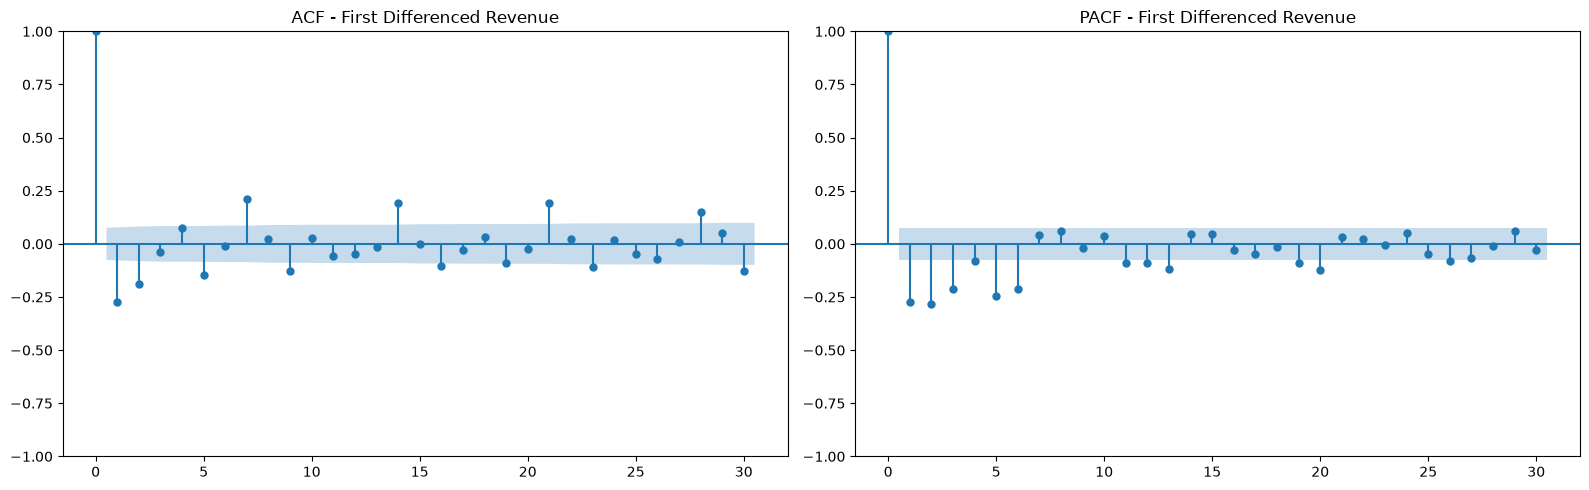

In [18]:
# ======================================================
# Section 18 - ACF and PACF Plots
# ======================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_acf(train_diff_1, lags=30, ax=axes[0])
axes[0].set_title("ACF - First Differenced Revenue")

plot_pacf(train_diff_1, lags=30, ax=axes[1], method="ywm")
axes[1].set_title("PACF - First Differenced Revenue")

plt.tight_layout()
plt.show()

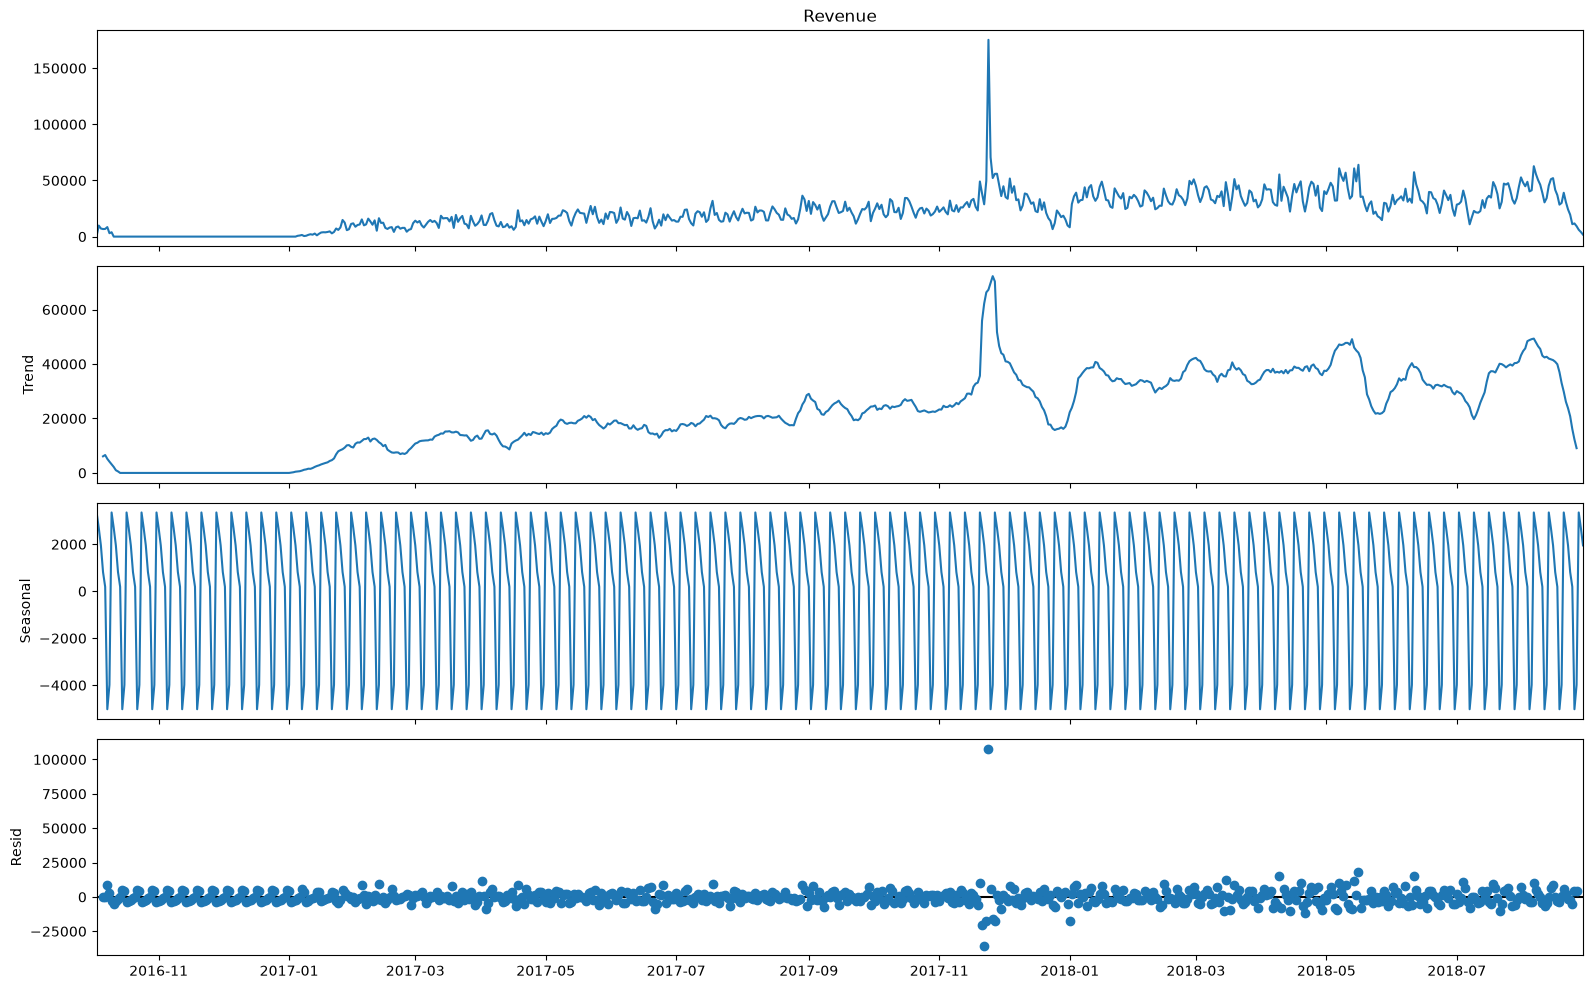

In [19]:
# ======================================================
# Section 19 - Seasonal Decomposition
# ======================================================

decomposition = seasonal_decompose(
    daily_revenue["Revenue"],
    model="additive",
    period=7
)

fig = decomposition.plot()
fig.set_size_inches(16, 10)
plt.tight_layout()
plt.show()

In [20]:
# ======================================================
# Section 20 - ARIMA Model
# ======================================================

from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train["Revenue"], order=(1, 1, 1))
arima_fitted = arima_model.fit()

print(arima_fitted.summary())

                               SARIMAX Results                                
Dep. Variable:                Revenue   No. Observations:                  666
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -6927.076
Date:                Sat, 04 Jul 2026   AIC                          13860.152
Time:                        13:49:06   BIC                          13873.651
Sample:                    10-03-2016   HQIC                         13865.383
                         - 07-30-2018                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3708      0.035     10.709      0.000       0.303       0.439
ma.L1         -0.8849      0.024    -37.485      0.000      -0.931      -0.839
sigma2      6.977e+07    1.1e-09   6.35e+16      0.0

### ARIMA Model Setup
The ARIMA order was selected based on a combination of stationarity testing, ACF/PACF inspection, and iterative model testing for forecasting performance.

In [21]:
# ======================================================
# Section 21 - ARIMA Forecast and Evaluation
# ======================================================

arima_forecast = arima_fitted.forecast(steps=len(test))

arima_mae = mean_absolute_error(test["Revenue"], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test["Revenue"], arima_forecast))

print("ARIMA MAE :", round(arima_mae, 2))
print("ARIMA RMSE:", round(arima_rmse, 2))

ARIMA MAE : 13399.19
ARIMA RMSE: 16707.98


### ARIMA Model Setup
The ARIMA order was selected based on a combination of stationarity testing, ACF/PACF inspection, and iterative model testing for forecasting performance.

In [22]:
# ======================================================
# Section 22 - SARIMA Model
# ======================================================

sarima_model = sm.tsa.statespace.SARIMAX(
    train["Revenue"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fitted = sarima_model.fit(disp=False)

print(sarima_fitted.summary())

                                     SARIMAX Results                                     
Dep. Variable:                           Revenue   No. Observations:                  666
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -6769.457
Date:                           Sat, 04 Jul 2026   AIC                          13548.915
Time:                                   13:49:08   BIC                          13571.292
Sample:                               10-03-2016   HQIC                         13557.595
                                    - 07-30-2018                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2706      0.069      3.929      0.000       0.136       0.406
ma.L1         -0.8017      0.055    -14.456

The final ARIMA configuration used in this notebook is ARIMA(p,d,q).

### SARIMA Model Setup
SARIMA extends ARIMA by explicitly modeling weekly seasonality using a seasonal period of 7 days. The seasonal order is included to test whether repeated weekly patterns improve forecast accuracy compared to non-seasonal ARIMA.

In [23]:
# ======================================================
# Section 23 - SARIMA Forecast and Evaluation
# ======================================================

sarima_forecast = sarima_fitted.forecast(steps=len(test))

sarima_mae = mean_absolute_error(test["Revenue"], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test["Revenue"], sarima_forecast))

print("SARIMA MAE :", round(sarima_mae, 2))
print("SARIMA RMSE:", round(sarima_rmse, 2))

SARIMA MAE : 12490.96
SARIMA RMSE: 17240.93


### Model Selection Rule
The best forecasting model is selected primarily based on lowest RMSE on the test set, since RMSE penalizes larger forecast errors more heavily and is suitable for revenue forecasting. MAE is also reported as a secondary interpretability metric.

In [24]:
# ======================================================
# Section 24 - Model Comparison
# ======================================================

# Recompute any metrics in case notebook cells were run out of order
# ------------------------------------------------------

# Baseline
if "baseline_forecast" not in globals():
    baseline_forecast = np.repeat(train["Revenue"].iloc[-1], len(test))

baseline_mae = mean_absolute_error(test["Revenue"], baseline_forecast)
baseline_rmse = np.sqrt(mean_squared_error(test["Revenue"], baseline_forecast))

# Holt-Winters
if "hw_forecast" not in globals():
    hw_model = ExponentialSmoothing(
        train["Revenue"],
        trend="add",
        seasonal="add",
        seasonal_periods=7
    ).fit()
    hw_forecast = hw_model.forecast(len(test))

hw_mae = mean_absolute_error(test["Revenue"], hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(test["Revenue"], hw_forecast))

# ARIMA
if "arima_forecast" not in globals():
    from statsmodels.tsa.arima.model import ARIMA
    arima_model = ARIMA(train["Revenue"], order=(1, 1, 1))
    arima_fitted = arima_model.fit()
    arima_forecast = arima_fitted.forecast(steps=len(test))

arima_mae = mean_absolute_error(test["Revenue"], arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test["Revenue"], arima_forecast))

# SARIMA
if "sarima_forecast" not in globals():
    sarima_model = sm.tsa.statespace.SARIMAX(
        train["Revenue"],
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    sarima_fitted = sarima_model.fit(disp=False)
    sarima_forecast = sarima_fitted.forecast(steps=len(test))

sarima_mae = mean_absolute_error(test["Revenue"], sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test["Revenue"], sarima_forecast))

# ------------------------------------------------------
# Create comparison table
# ------------------------------------------------------

comparison_df = pd.DataFrame({
    "Model": ["Baseline", "Holt-Winters", "ARIMA", "SARIMA"],
    "MAE": [baseline_mae, hw_mae, arima_mae, sarima_mae],
    "RMSE": [baseline_rmse, hw_rmse, arima_rmse, sarima_rmse]
})

comparison_df = comparison_df.sort_values("RMSE").reset_index(drop=True)

display(comparison_df)

best_model_name = comparison_df.loc[0, "Model"]
print("Best model based on RMSE:", best_model_name)

,Model,MAE,RMSE
0,ARIMA,13399.188064,16707.978281
1,SARIMA,12490.955288,17240.933115
2,Holt-Winters,12912.405738,17902.653510
3,Baseline,14381.775000,19154.297300


Best model based on RMSE: ARIMA


### Why ARIMA was selected
Although SARIMA and Holt-Winters produced slightly lower MAE, ARIMA achieved the lowest RMSE, which indicates better control over larger forecast errors. Since revenue forecasting is sensitive to large misses, ARIMA was selected as the final model.

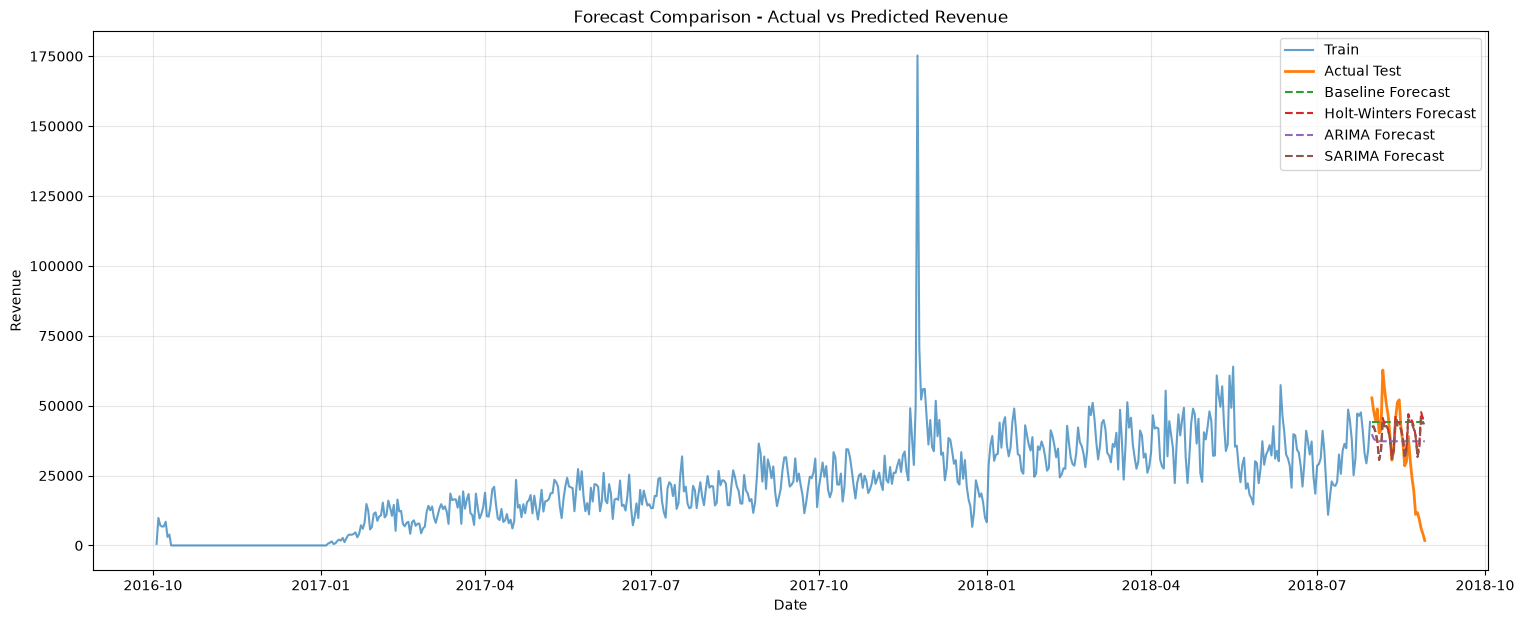

In [25]:
# ======================================================
# Section 25 - Compare Forecasts Visually
# ======================================================

plt.figure(figsize=(18, 7))

plt.plot(train.index, train["Revenue"], label="Train", alpha=0.7)
plt.plot(test.index, test["Revenue"], label="Actual Test", linewidth=2)

plt.plot(test.index, baseline_forecast, label="Baseline Forecast", linestyle="--")
plt.plot(test.index, hw_forecast, label="Holt-Winters Forecast", linestyle="--")
plt.plot(test.index, arima_forecast, label="ARIMA Forecast", linestyle="--")
plt.plot(test.index, sarima_forecast, label="SARIMA Forecast", linestyle="--")

plt.title("Forecast Comparison - Actual vs Predicted Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Final Forecast Generation
After selecting the best-performing model on the train-test evaluation, the model is retrained on the full historical daily revenue series before generating the final 30-day forecast.

In [26]:
# ======================================================
# Section 26 - Retrain Best Model on Full Data
# ======================================================

full_series = daily_revenue["Revenue"].copy()

best_model_name = comparison_df.loc[0, "Model"]
print("Best model selected for final forecasting:", best_model_name)

if best_model_name == "Baseline":
    final_model = None   # no fitted model needed
    print("Baseline selected - future forecast will use last observed value.")

elif best_model_name == "Holt-Winters":
    final_model = ExponentialSmoothing(
        full_series,
        trend="add",
        seasonal="add",
        seasonal_periods=7
    ).fit()
    print("Holt-Winters model retrained on full dataset.")

elif best_model_name == "ARIMA":
    from statsmodels.tsa.arima.model import ARIMA
    final_model = ARIMA(full_series, order=(1, 1, 1)).fit()
    print("ARIMA model retrained on full dataset.")

elif best_model_name == "SARIMA":
    final_model = sm.tsa.statespace.SARIMAX(
        full_series,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 7),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    print("SARIMA model retrained on full dataset.")

else:
    raise ValueError("Unexpected model name found in comparison_df")

Best model selected for final forecasting: ARIMA
ARIMA model retrained on full dataset.


In [29]:
# ======================================================
# Section 27 - Forecast Next 30 Days
# ======================================================

forecast_horizon = 30

if best_model_name == "Baseline":
    future_forecast = np.repeat(full_series.iloc[-1], forecast_horizon)

else:
    future_forecast = final_model.forecast(steps=forecast_horizon)

future_dates = pd.date_range(
    start=full_series.index.max() + pd.Timedelta(days=1),
    periods=forecast_horizon,
    freq="D"
)

future_forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted_Revenue": future_forecast
})


display(future_forecast_df.head())
display(future_forecast_df.tail())

,Date,Forecasted_Revenue
2018-08-30,2018-08-30,9737.431835
2018-08-31,2018-08-31,12581.310044
2018-09-01,2018-09-01,13595.468694
2018-09-02,2018-09-02,13957.128965
2018-09-03,2018-09-03,14086.101047


,Date,Forecasted_Revenue
2018-09-24,2018-09-24,14157.586402
2018-09-25,2018-09-25,14157.586402
2018-09-26,2018-09-26,14157.586402
2018-09-27,2018-09-27,14157.586402
2018-09-28,2018-09-28,14157.586402


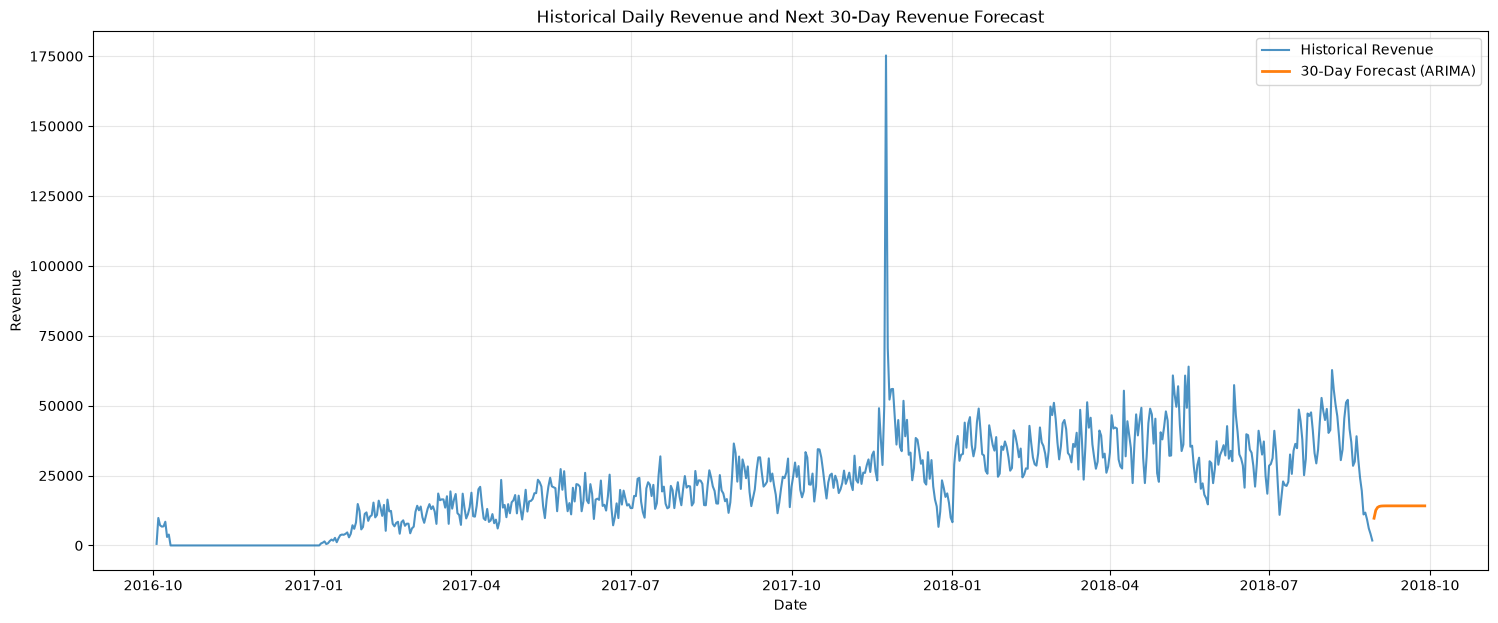

In [30]:
# ======================================================
# Section 28 - Plot Historical Revenue with Future Forecast
# ======================================================

plt.figure(figsize=(18, 7))

plt.plot(full_series.index, full_series.values, label="Historical Revenue", alpha=0.8)
plt.plot(
    future_forecast_df["Date"],
    future_forecast_df["Forecasted_Revenue"],
    label=f"30-Day Forecast ({best_model_name})",
    linewidth=2
)

plt.title("Historical Daily Revenue and Next 30-Day Revenue Forecast")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
# ======================================================
# Section 29 - Forecast Summary
# ======================================================

forecast_summary = {
    "Best Model": best_model_name,
    "Forecast Horizon (Days)": forecast_horizon,
    "Forecast Start Date": future_forecast_df["Date"].min(),
    "Forecast End Date": future_forecast_df["Date"].max(),
    "Total Forecasted Revenue": round(future_forecast_df["Forecasted_Revenue"].sum(), 2),
    "Average Daily Forecasted Revenue": round(future_forecast_df["Forecasted_Revenue"].mean(), 2),
    "Minimum Forecasted Revenue": round(future_forecast_df["Forecasted_Revenue"].min(), 2),
    "Maximum Forecasted Revenue": round(future_forecast_df["Forecasted_Revenue"].max(), 2)
}

forecast_summary_df = pd.DataFrame([forecast_summary])
display(forecast_summary_df)

,Best Model,Forecast Horizon (Days),Forecast Start Date,Forecast End Date,Total Forecasted Revenue,Average Daily Forecasted Revenue,Minimum Forecasted Revenue,Maximum Forecasted Revenue
0,ARIMA,30,2018-08-30,2018-09-28,417857.48,13928.58,9737.43,14157.59


# Final Conclusion

## Summary
In this notebook, a time-series forecasting workflow was built to predict future **daily revenue** for the Olist e-commerce marketplace.

The forecasting pipeline included:
- extracting delivered-order revenue from the Olist dataset
- creating a clean daily revenue time series
- performing time-series exploration using trend plots, rolling statistics, ADF testing, ACF/PACF, and seasonal decomposition
- splitting the data into train and test sets
- comparing multiple forecasting approaches:
  - Baseline / Naive Forecast
  - Holt-Winters Exponential Smoothing
  - ARIMA
  - SARIMA

The best-performing model was selected based on forecast error metrics such as **MAE** and **RMSE**, and then retrained on the full historical revenue series to generate a **30-day future revenue forecast**.

## Business Value
This forecasting workflow extends the descriptive analytics and Power BI dashboard by adding a predictive layer. The forecast can help business stakeholders:
- estimate near-term revenue expectations
- prepare sellers and operations for expected demand
- support inventory and financial planning
- identify trend continuation or slowdown risk

## Key Learning
This notebook demonstrates how e-commerce transaction data can be transformed into a forecasting-ready time series and how classical statistical models can be used to generate actionable revenue forecasts for business planning.